For this notebook, we test the data sample using different setups for obtaining $\gamma_{\mathrm{PPN}}$ in the following scenarios:

- Cao et al. (2015): $\sigma_v$
- Cao et al. (2015): $\sigma_0$
- Cao et al. (2017): $\sigma_v$
- Cao et al. (2017): $\sigma_0$
- Chen et al. (2019): $\sigma_v$
- Chen et al. (2019): $\sigma_0$
- Liu et al. (2022): $\sigma_v$
- Liu et al. (2022): $\sigma_0$

In [1]:
import getdist
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rings2cosmo
from getdist import MCSamples, plots

pd.set_option("display.max_colwidth", None)

%matplotlib inline

In [2]:
mpl.rcParams.update(
    {
        "font.size": 20,
        "pgf.texsystem": "pdflatex",
        "font.family": "serif",
        "text.usetex": True,
    }
)

# Data used for plotting and `rings2cosmo` script to obtain gamma_PPN:
colors = plt.cm.turbo(np.linspace(0.1, 0.9, 20))
labels = [r"\alpha", r"\beta", r"\delta", r"\gamma"]

In [3]:
# Loading the data
Cao_Data = pd.read_csv("03_Cao_et_al._(2015)_Data.csv")
Chen_Data = pd.read_csv("03_Chen_et_al._(2019)_Data.csv")
len(Cao_Data), len(Chen_Data)

(118, 161)

Priors for each value:

- $\alpha$: Total mass density index
- $\beta$: Anisotropy parameter
- $\delta$: Luminosity density index
- $\gamma$: Parameterized Post-Newtonian parameter

In [4]:
alpha_true = 2
beta_true = 0.18
delta_true = 2.4
gamma_true = 1
nsteps = 15_000  # Number of steps

In [5]:
def get_mcmc(z_L, z_S, theta_E, theta_ap, seeing_atm, velDisp, velDispErr, label):
    sampler = rings2cosmo.logprobability_sampling(
        z_S,
        z_L,
        velDisp,
        velDispErr,
        theta_E,
        seeing_atm,
        theta_ap,
        seed=42,
        alpha_ini=alpha_true,
        beta_ini=beta_true,
        delta_ini=delta_true,
        gamma_ini=gamma_true,
        alpha_0_value=alpha_true,
        eps_alpha_0_value=0.08,
        beta_0_value=beta_true,
        eps_beta_0_value=0.13,
        delta_0_value=delta_true,
        eps_delta_0_value=0.11,
        n_dim=4,
        n_walkers=64,
        n_burn=500,
        n_steps=nsteps,
        progress="notebook",
        processes=64,
    )
    samples = MCSamples(
        samples=sampler.get_chain(discard=500, thin=1, flat=True),
        names=["alpha", "beta", "delta", "gamma"],
        labels=labels,
        label=label,
    )
    # Customized triangle plot
    g = plots.get_subplot_plotter(subplot_size=4)
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.5
    g.settings.title_limit_fontsize = 20
    g.settings.axes_fontsize = 20
    g.settings.axes_labelsize = 20
    g.settings.legend_fontsize = 20
    g.triangle_plot(
        [samples],
        filled=True,
        legend_labels=[label],
        legend_loc="upper right",
        line_args=[{"ls": "--", "color": "black"}],
        contour_colors=["black"],
        title_limit=1,
        markers={
            "alpha": alpha_true,
            "beta": beta_true,
            "delta": delta_true,
            "gamma": gamma_true,
        },
    )
    return samples

# 1. Cao et al. (2015): $\sigma_v$

In [6]:
Cao_Data.head()

,JNAME,Cao_Name,in_cao_2017,in_lastberu_cosmo_ground,Cao_z_L,Cao_z_S,Cao_velDisp,Cao_velDispErr,Cao_velDisp0,Cao_velDisp0Err,Cao_theta_E,Cao_theta_E_rad,Cao_theta_ap,Cao_theta_ap_rad,Cao_theta_eff,Cao_theta_eff_rad,Cao_Survey,Cao_Seeing_atm,Cao_Seeing_atm_rad
0,J015107.4+004909.0,J0151+0049,True,False,0.517,1.364,219,39,231.021476,42.174676,0.68,0.000003,1.0,0.000005,0.89,0.000004,BELLS,1.8,0.000009
1,J074724.1+505537.5,J0747+5055,False,False,0.438,0.898,328,60,338.513499,62.977233,0.75,0.000004,1.0,0.000005,1.24,0.000006,BELLS,1.8,0.000009
2,J074734.8+444859.3,J0747+4448,True,False,0.437,0.897,281,52,274.381038,51.541879,0.61,0.000003,1.0,0.000005,2.87,0.000014,BELLS,1.8,0.000009
3,J080105.3+472749.6,J0801+4727,False,False,0.483,1.518,98,24,106.464867,26.635573,0.49,0.000002,1.0,0.000005,0.57,0.000003,BELLS,1.8,0.000009
4,J083049.7+511631.8,J0830+5116,True,False,0.530,1.332,268,36,278.785933,38.763604,1.14,0.000006,1.0,0.000005,1.10,0.000005,BELLS,1.8,0.000009


Running burn-in ...


  0%|          | 0/500 [00:00<?, ?it/s]

Sampling ...


  0%|          | 0/15000 [00:00<?, ?it/s]

Removed no burn in


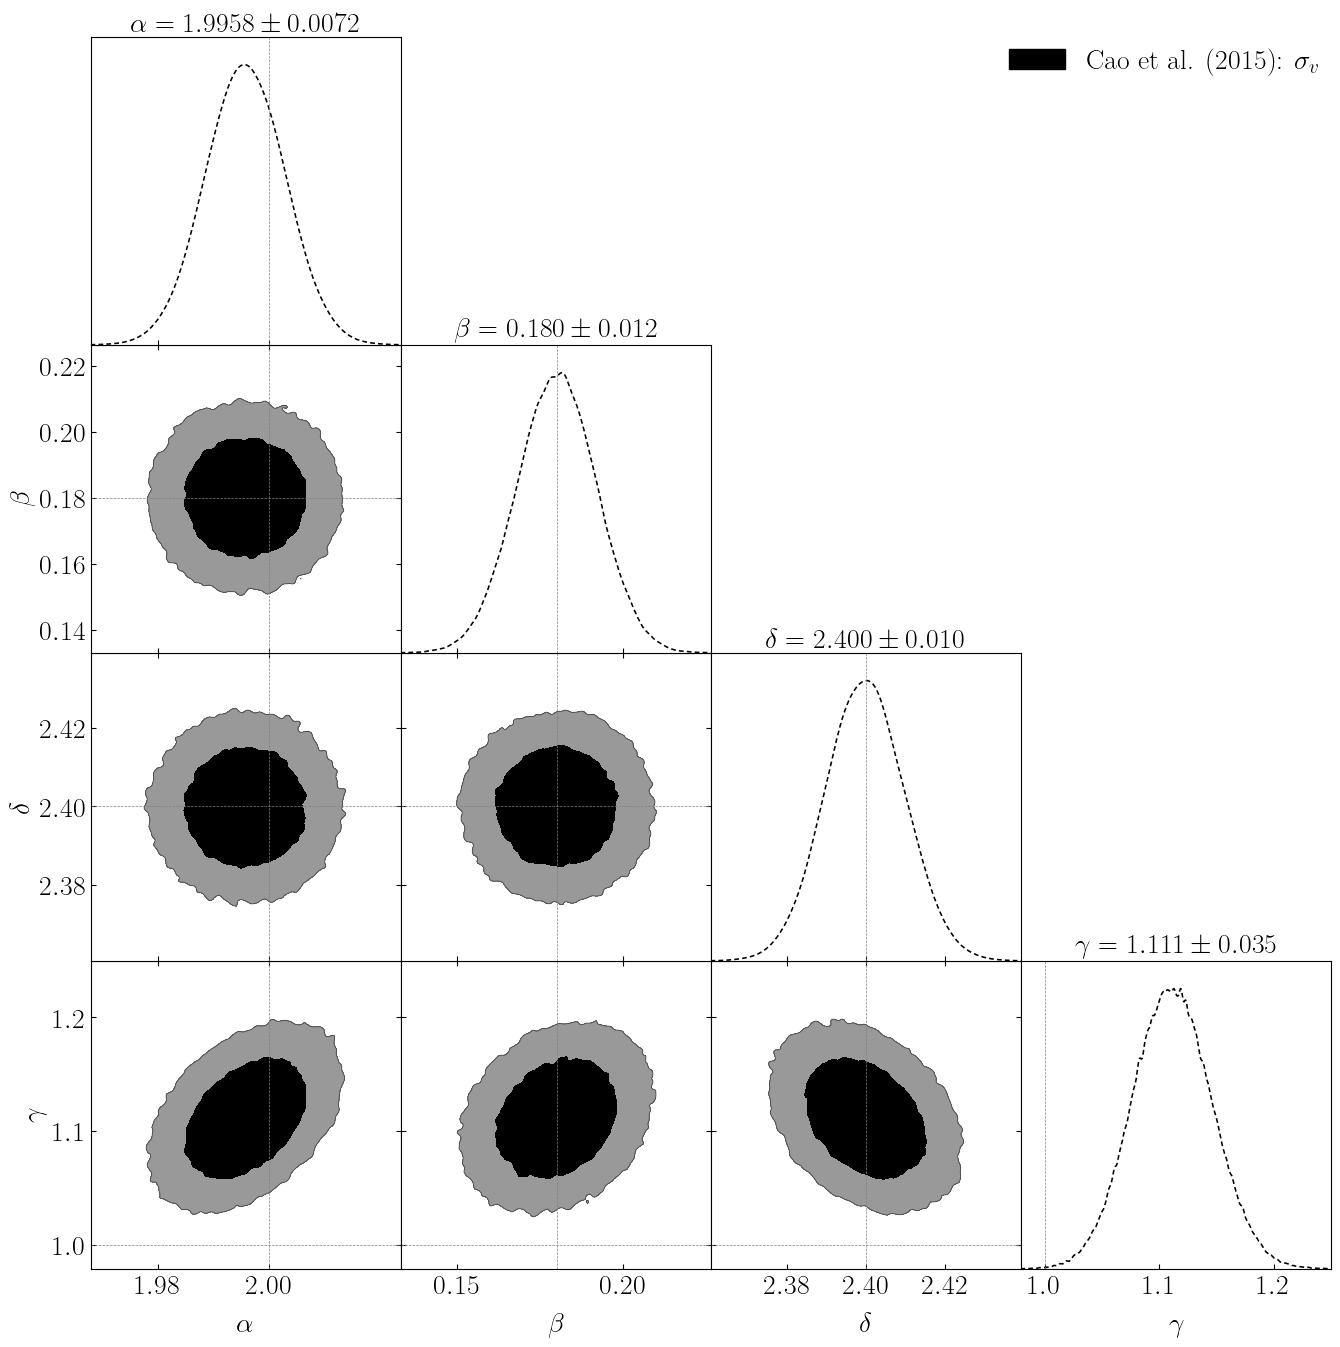

In [7]:
case_1 = get_mcmc(
    z_L=Cao_Data["Cao_z_L"].values,
    z_S=Cao_Data["Cao_z_S"].values,
    theta_E=Cao_Data["Cao_theta_E_rad"].values,
    theta_ap=Cao_Data["Cao_theta_ap_rad"].values,
    seeing_atm=Cao_Data["Cao_Seeing_atm_rad"].values,
    velDisp=Cao_Data["Cao_velDisp"].values,
    velDispErr=Cao_Data["Cao_velDispErr"].values,
    label="Cao et al. (2015): $\sigma_v$",
)

# 2. Cao et al. (2015): $\sigma_0$

Running burn-in ...


  0%|          | 0/500 [00:00<?, ?it/s]

Sampling ...


  0%|          | 0/15000 [00:00<?, ?it/s]

Removed no burn in


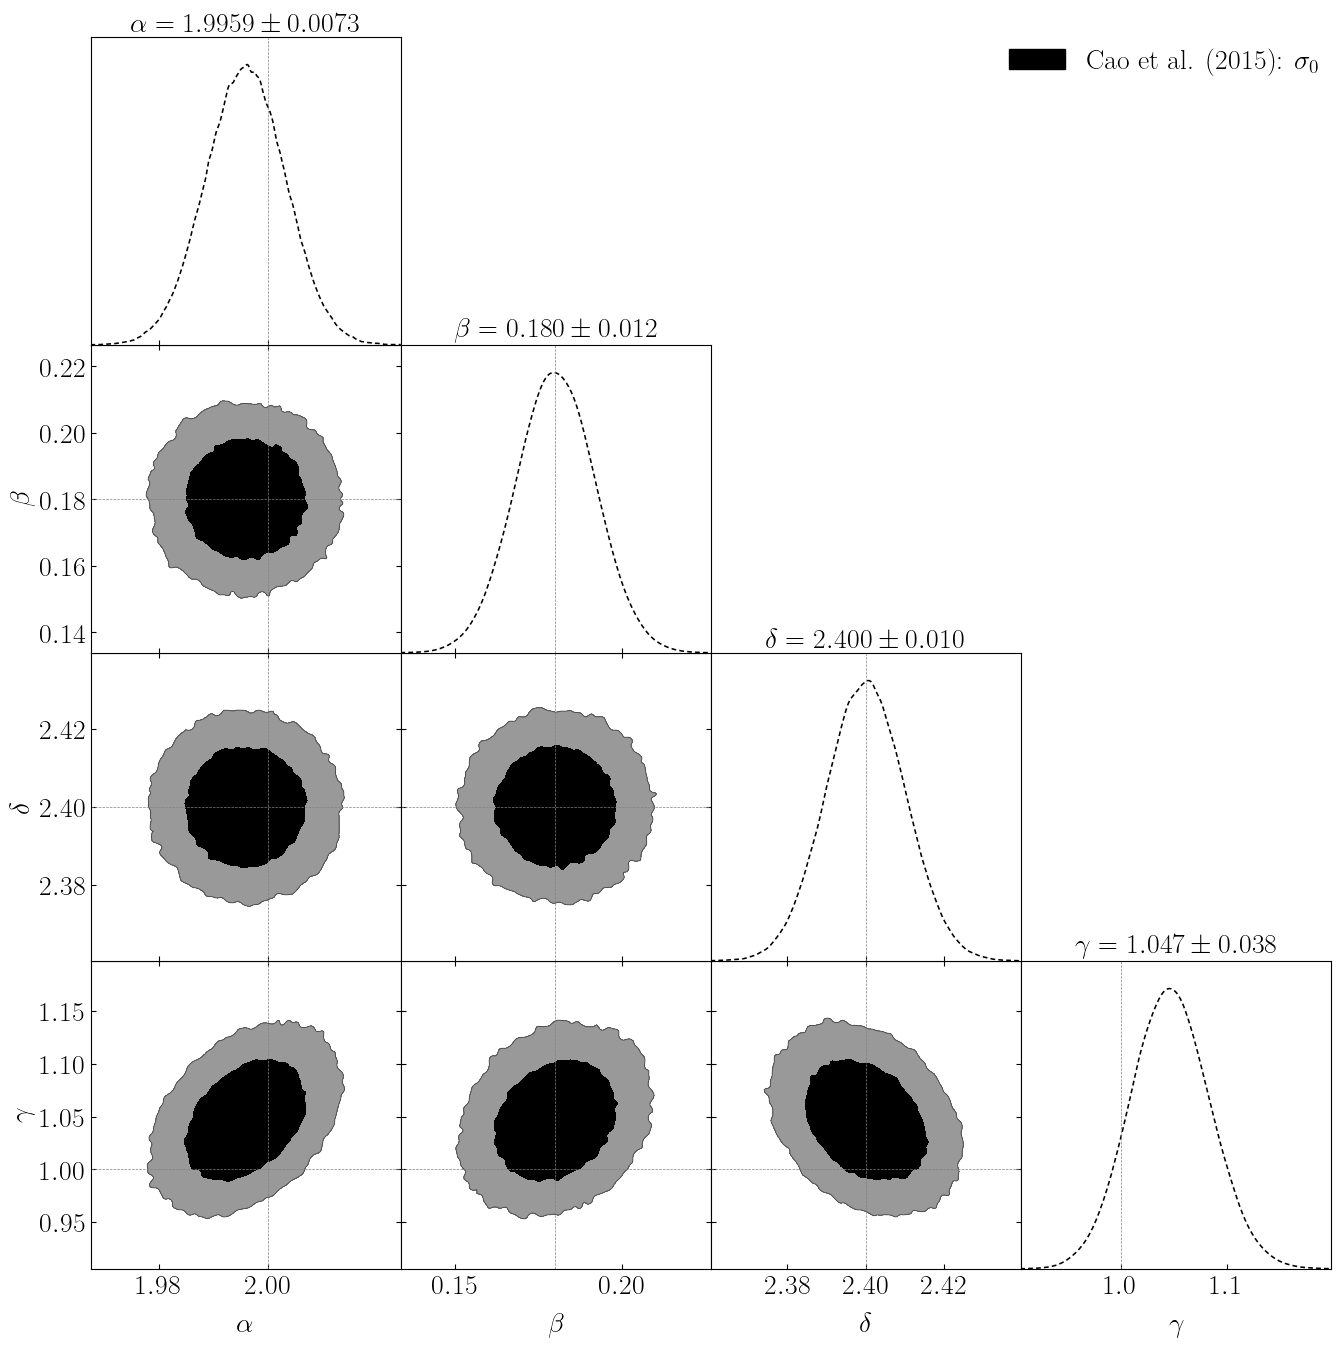

In [8]:
case_2 = get_mcmc(
    z_L=Cao_Data["Cao_z_L"].values,
    z_S=Cao_Data["Cao_z_S"].values,
    theta_E=Cao_Data["Cao_theta_E_rad"].values,
    theta_ap=Cao_Data["Cao_theta_ap_rad"].values,
    seeing_atm=Cao_Data["Cao_Seeing_atm_rad"].values,
    velDisp=Cao_Data["Cao_velDisp0"].values,
    velDispErr=Cao_Data["Cao_velDisp0Err"].values,
    label="Cao et al. (2015): $\sigma_0$",
)

# 3. Cao et al. (2017): $\sigma_v$

In [9]:
Cao_Data_2017 = Cao_Data.query("in_cao_2017==True")
len(Cao_Data_2017)

80

Running burn-in ...


  0%|          | 0/500 [00:00<?, ?it/s]

Sampling ...


  0%|          | 0/15000 [00:00<?, ?it/s]

Removed no burn in


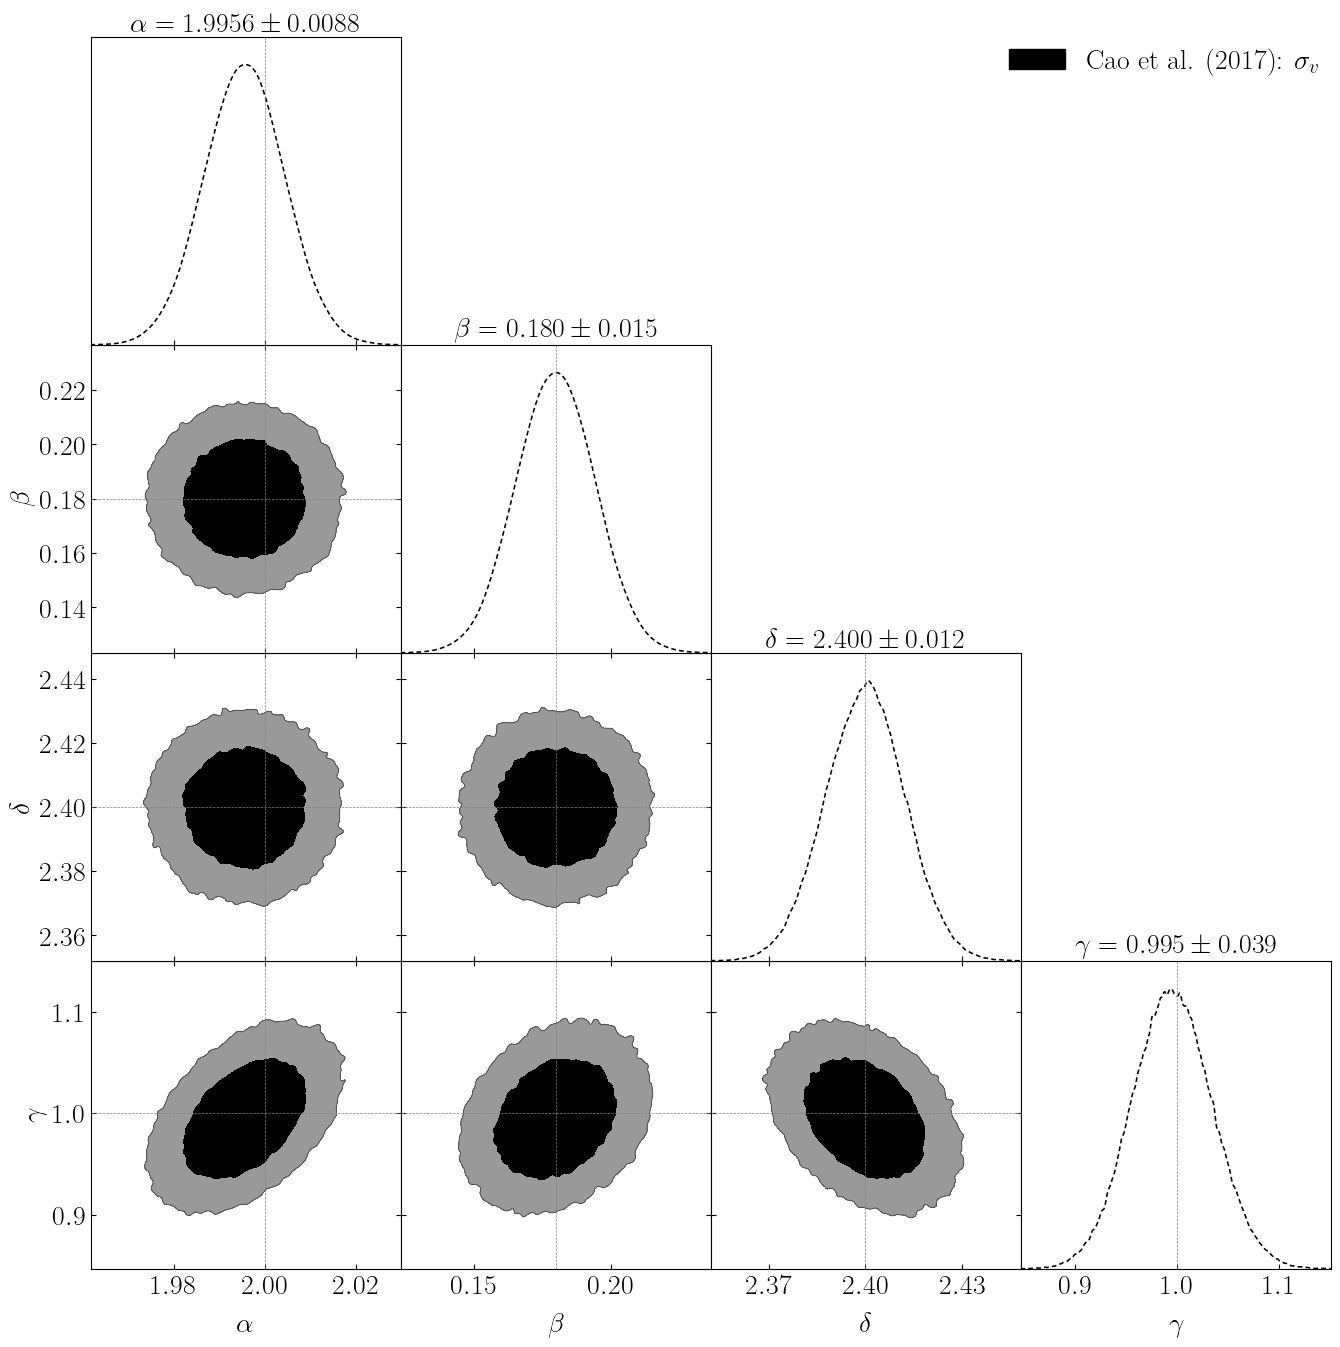

In [10]:
case_3 = get_mcmc(
    z_L=Cao_Data_2017["Cao_z_L"].values,
    z_S=Cao_Data_2017["Cao_z_S"].values,
    theta_E=Cao_Data_2017["Cao_theta_E_rad"].values,
    theta_ap=Cao_Data_2017["Cao_theta_ap_rad"].values,
    seeing_atm=Cao_Data_2017["Cao_Seeing_atm_rad"].values,
    velDisp=Cao_Data_2017["Cao_velDisp"].values,
    velDispErr=Cao_Data_2017["Cao_velDispErr"].values,
    label="Cao et al. (2017): $\sigma_v$",
)

# 4. Cao et al. (2017): $\sigma_0$

Running burn-in ...


  0%|          | 0/500 [00:00<?, ?it/s]

Sampling ...


  0%|          | 0/15000 [00:00<?, ?it/s]

Removed no burn in


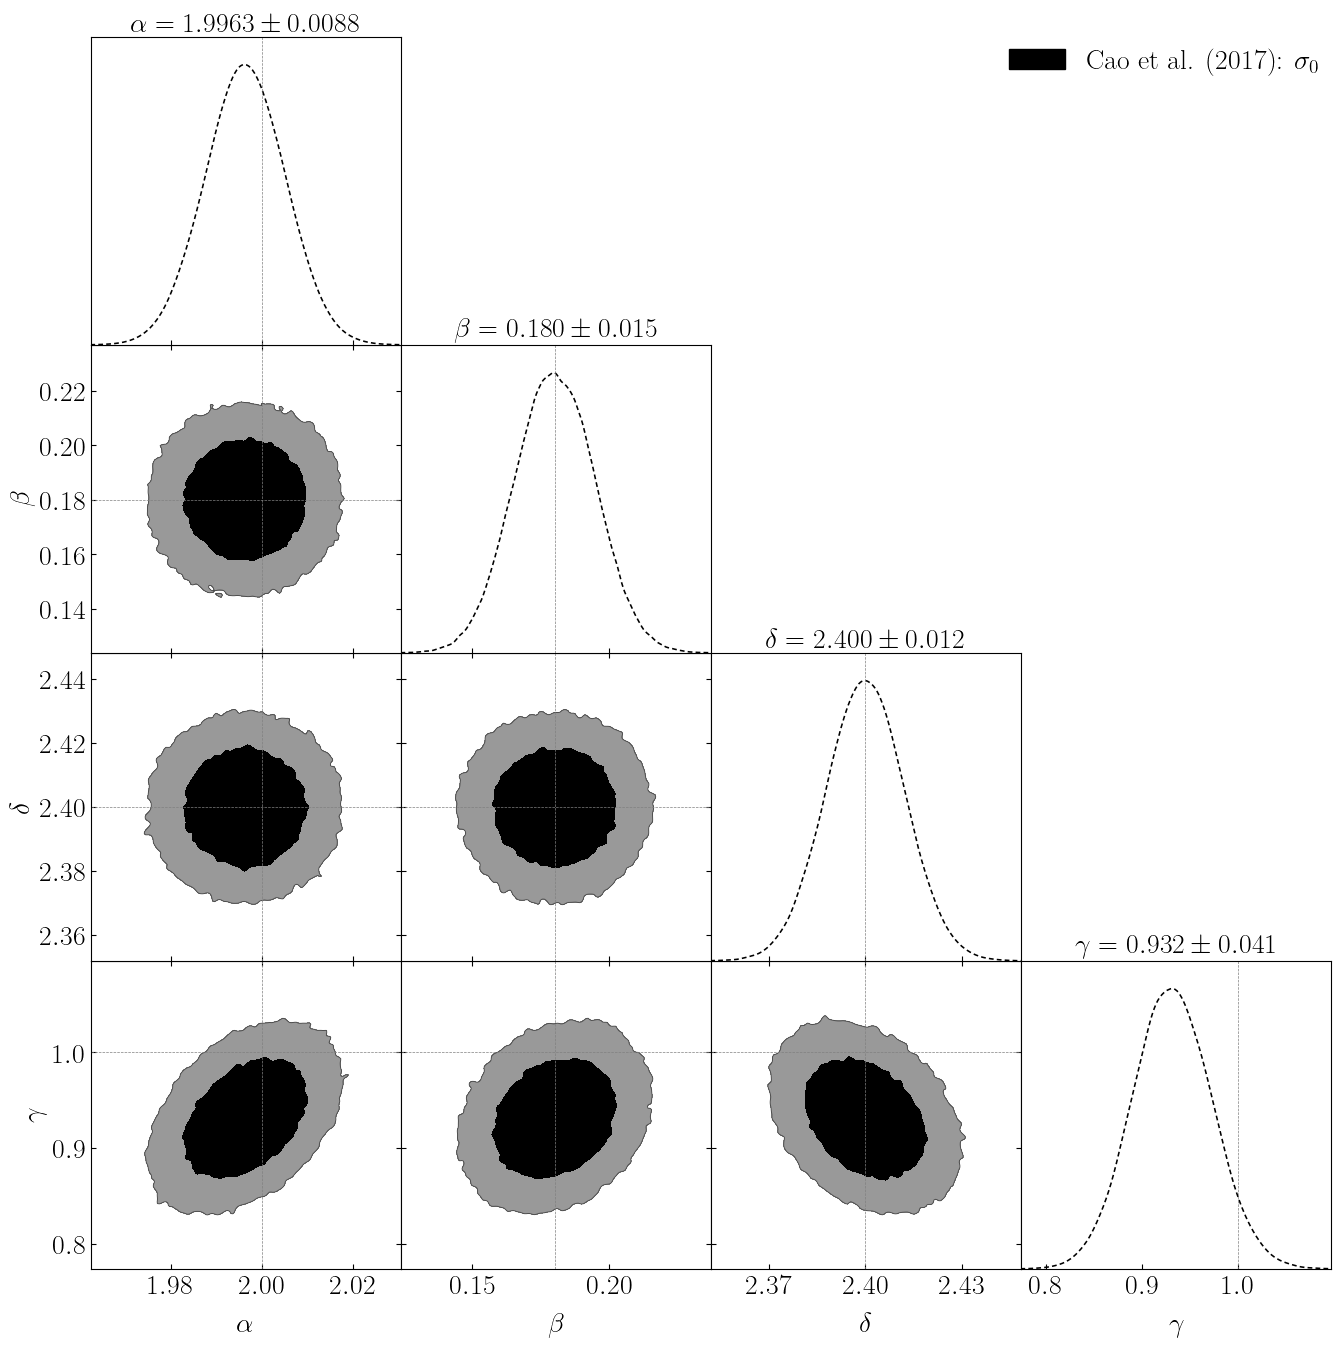

In [11]:
case_4 = get_mcmc(
    z_L=Cao_Data_2017["Cao_z_L"].values,
    z_S=Cao_Data_2017["Cao_z_S"].values,
    theta_E=Cao_Data_2017["Cao_theta_E_rad"].values,
    theta_ap=Cao_Data_2017["Cao_theta_ap_rad"].values,
    seeing_atm=Cao_Data_2017["Cao_Seeing_atm_rad"].values,
    velDisp=Cao_Data_2017["Cao_velDisp0"].values,
    velDispErr=Cao_Data_2017["Cao_velDisp0Err"].values,
    label="Cao et al. (2017): $\sigma_0$",
)

# 5. Chen et al. (2019): $\sigma_v$

Running burn-in ...


  0%|          | 0/500 [00:00<?, ?it/s]

Sampling ...


  0%|          | 0/15000 [00:00<?, ?it/s]

Removed no burn in


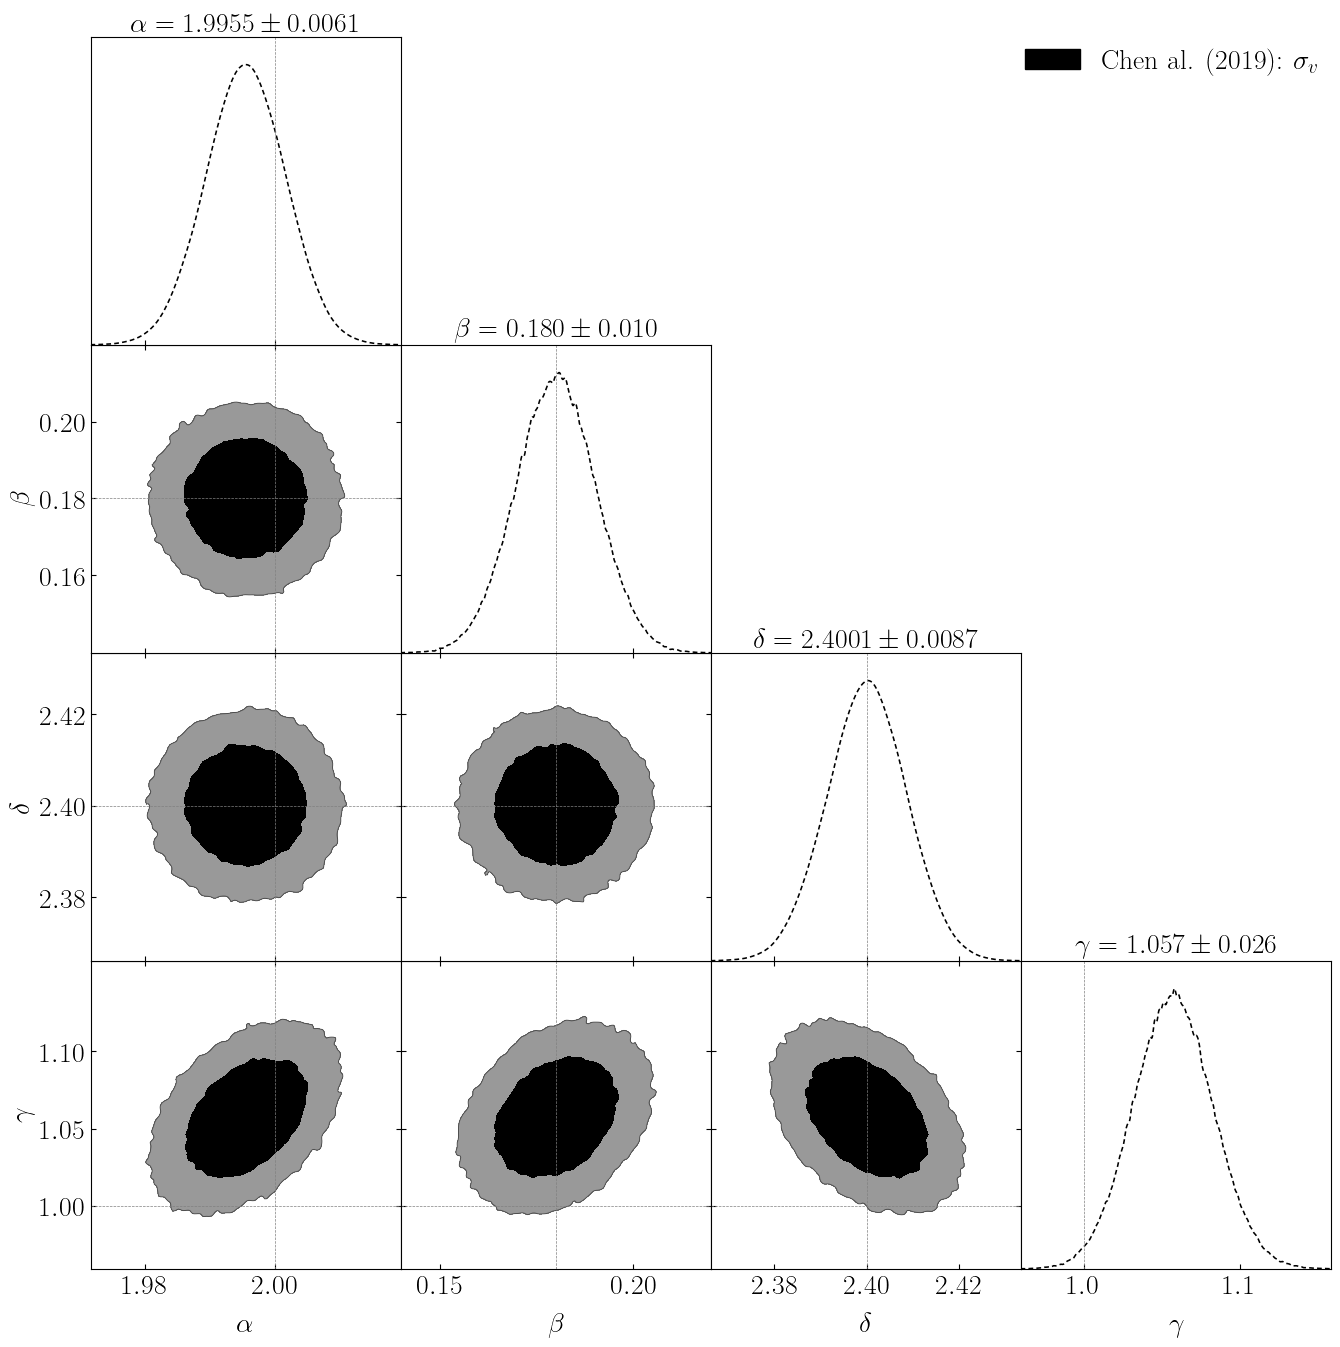

In [12]:
case_5 = get_mcmc(
    z_L=Chen_Data["Chen_z_L"].values,
    z_S=Chen_Data["Chen_z_S"].values,
    theta_E=Chen_Data["Chen_theta_E_rad"].values,
    theta_ap=Chen_Data["Chen_theta_ap_rad"].values,
    seeing_atm=Chen_Data["Chen_Seeing_atm_rad"].values,
    velDisp=Chen_Data["Chen_velDisp"].values,
    velDispErr=Chen_Data["Chen_velDispErr"].values,
    label="Chen al. (2019): $\sigma_v$",
)

# 6. Chen et al. (2019): $\sigma_0$

Running burn-in ...


  0%|          | 0/500 [00:00<?, ?it/s]

Sampling ...


  0%|          | 0/15000 [00:00<?, ?it/s]

Removed no burn in


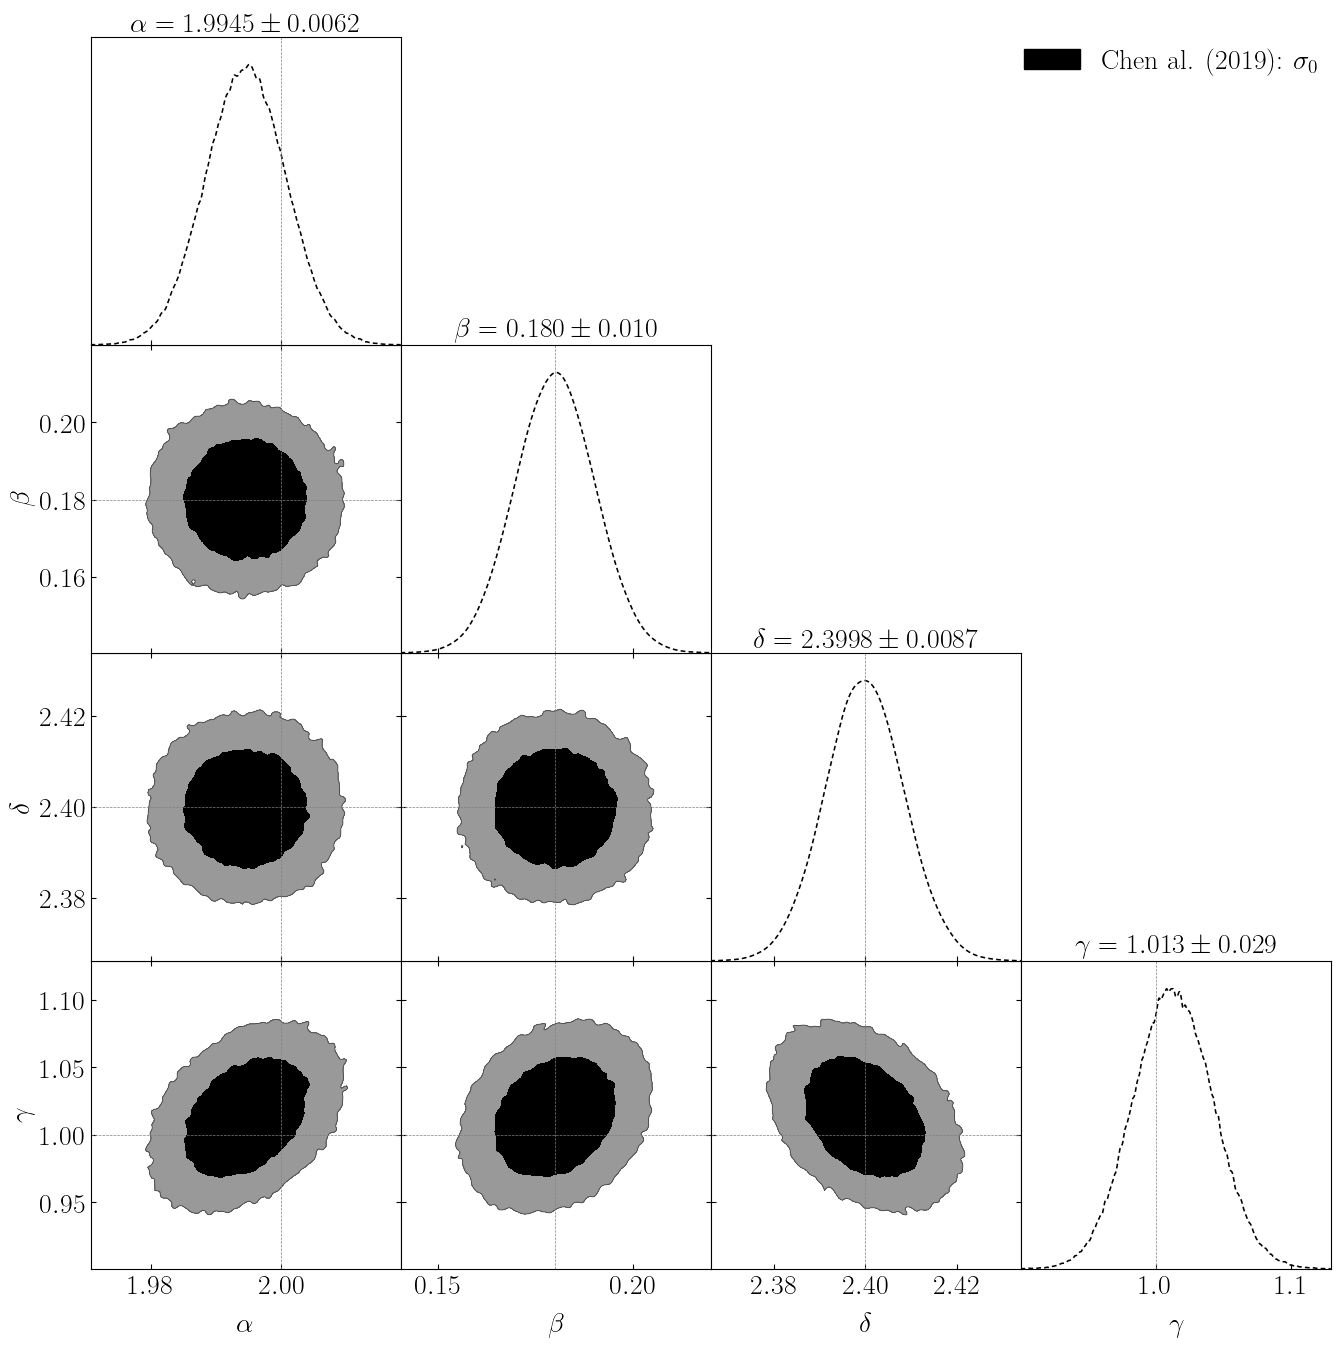

In [13]:
case_6 = get_mcmc(
    z_L=Chen_Data["Chen_z_L"].values,
    z_S=Chen_Data["Chen_z_S"].values,
    theta_E=Chen_Data["Chen_theta_E_rad"].values,
    theta_ap=Chen_Data["Chen_theta_ap_rad"].values,
    seeing_atm=Chen_Data["Chen_Seeing_atm_rad"].values,
    velDisp=Chen_Data["Chen_velDisp0"].values,
    velDispErr=Chen_Data["Chen_velDisp0Err"].values,
    label="Chen al. (2019): $\sigma_0$",
)

# 7. Liu et al. (2022): $\sigma_v$

In [14]:
Liu_Data = Chen_Data.query("in_liu_2022==True")
len(Liu_Data)

120

Running burn-in ...


  0%|          | 0/500 [00:00<?, ?it/s]

Sampling ...


  0%|          | 0/15000 [00:00<?, ?it/s]

Removed no burn in


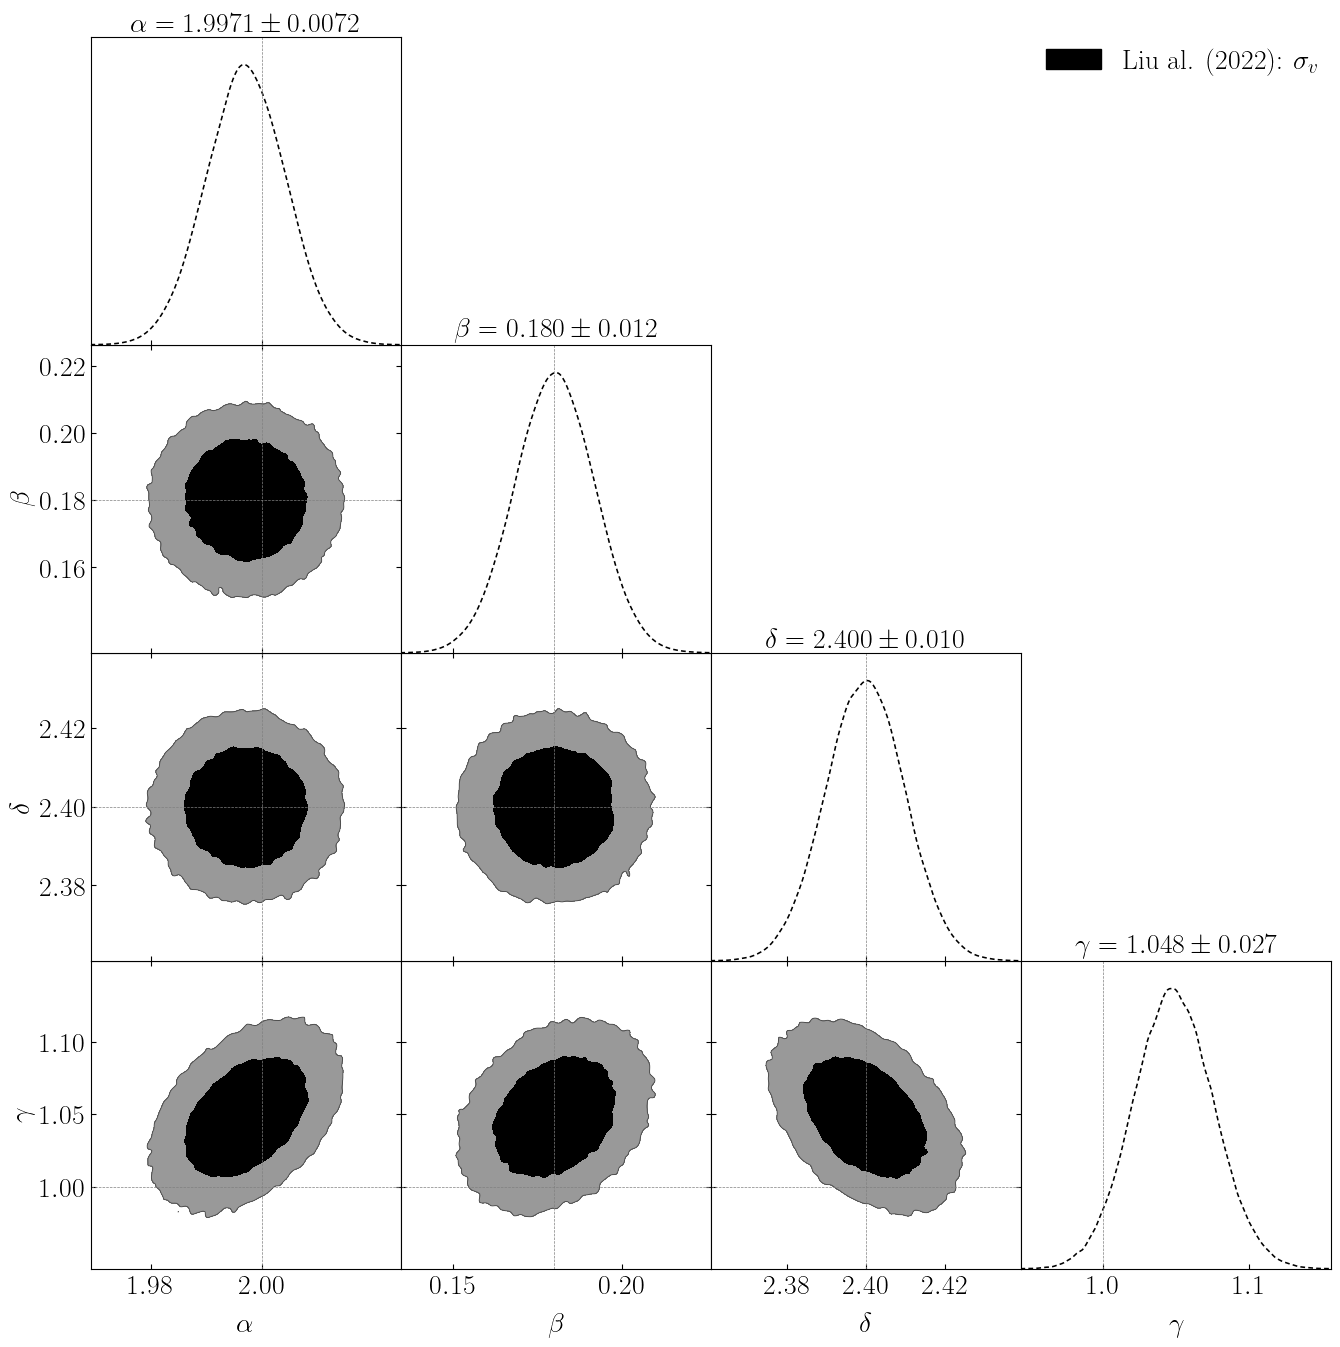

In [15]:
case_7 = get_mcmc(
    z_L=Liu_Data["Chen_z_L"].values,
    z_S=Liu_Data["Chen_z_S"].values,
    theta_E=Liu_Data["Chen_theta_E_rad"].values,
    theta_ap=Liu_Data["Chen_theta_ap_rad"].values,
    seeing_atm=Liu_Data["Chen_Seeing_atm_rad"].values,
    velDisp=Liu_Data["Chen_velDisp"].values,
    velDispErr=Liu_Data["Chen_velDispErr"].values,
    label="Liu al. (2022): $\sigma_v$",
)

# 8. Liu et al. (2022): $\sigma_0$

Running burn-in ...


  0%|          | 0/500 [00:00<?, ?it/s]

Sampling ...


  0%|          | 0/15000 [00:00<?, ?it/s]

Removed no burn in


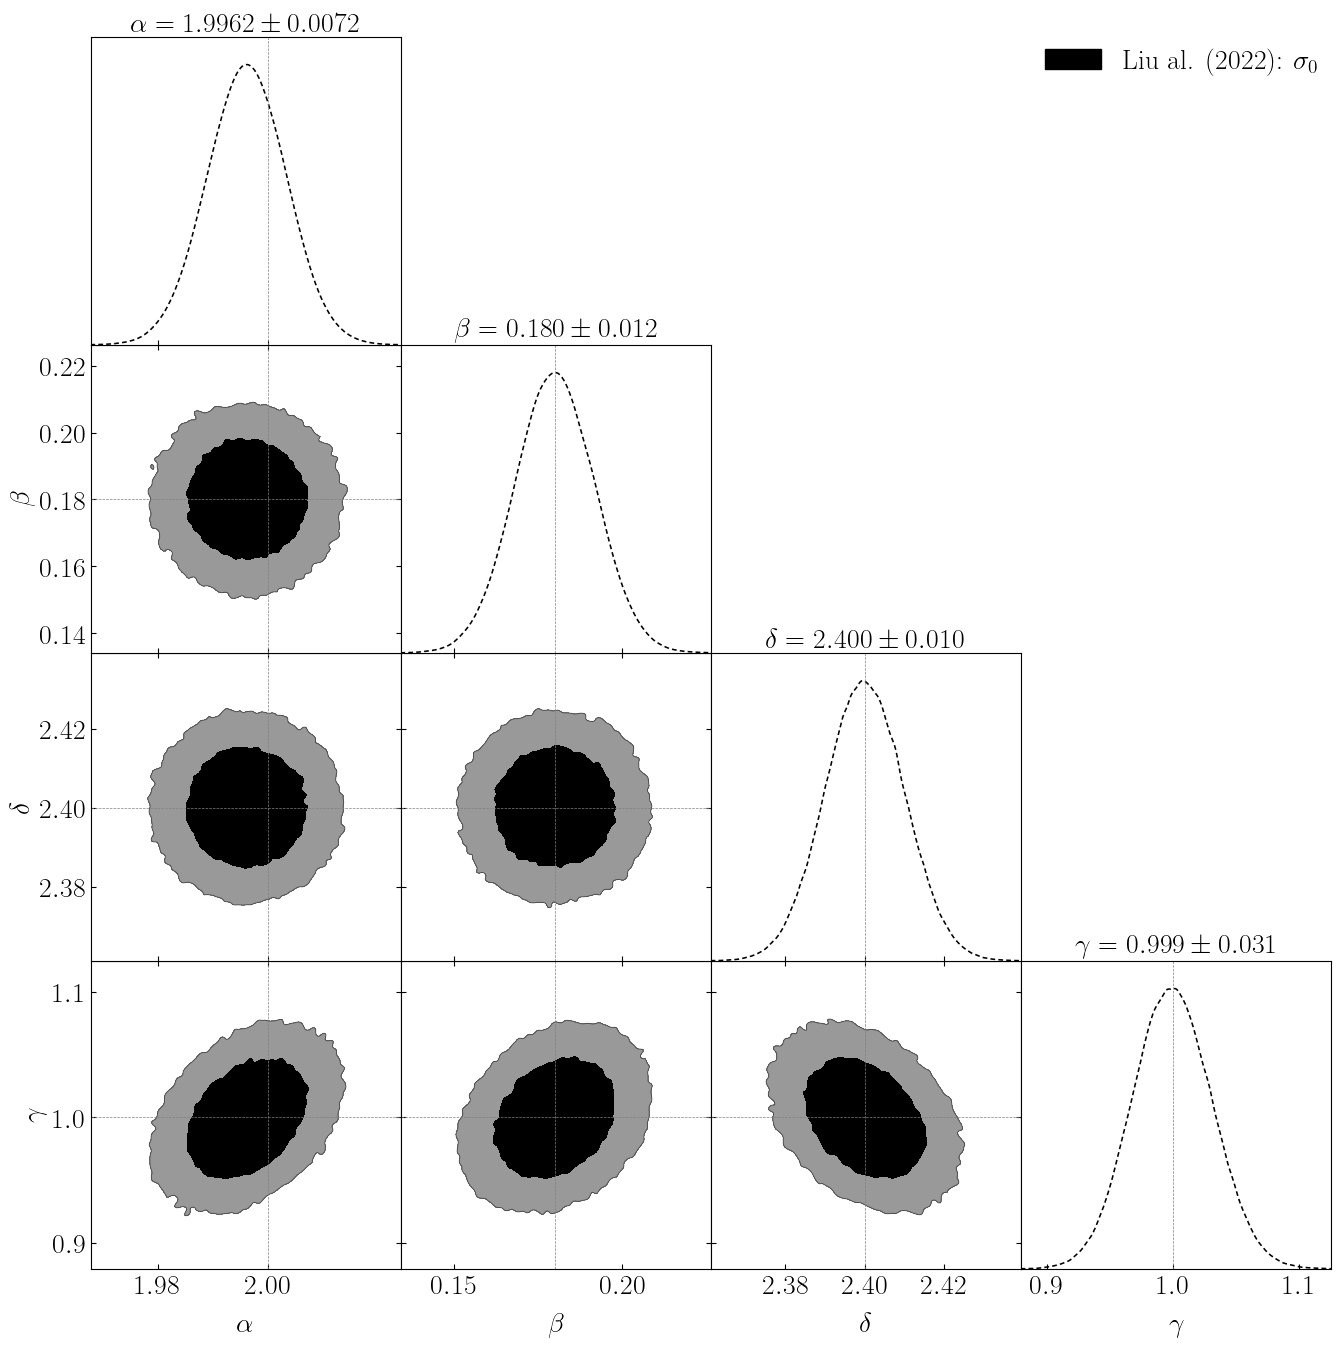

In [16]:
case_8 = get_mcmc(
    z_L=Liu_Data["Chen_z_L"].values,
    z_S=Liu_Data["Chen_z_S"].values,
    theta_E=Liu_Data["Chen_theta_E_rad"].values,
    theta_ap=Liu_Data["Chen_theta_ap_rad"].values,
    seeing_atm=Liu_Data["Chen_Seeing_atm_rad"].values,
    velDisp=Liu_Data["Chen_velDisp0"].values,
    velDispErr=Liu_Data["Chen_velDisp0Err"].values,
    label="Liu al. (2022): $\sigma_0$",
)

# Results

In [17]:
full_stats = [
    np.hstack([case_1.getMeans(), np.sqrt(case_1.getVars())]).T,
    np.hstack([case_2.getMeans(), np.sqrt(case_2.getVars())]).T,
    np.hstack([case_3.getMeans(), np.sqrt(case_3.getVars())]).T,
    np.hstack([case_4.getMeans(), np.sqrt(case_4.getVars())]).T,
    np.hstack([case_5.getMeans(), np.sqrt(case_5.getVars())]).T,
    np.hstack([case_6.getMeans(), np.sqrt(case_6.getVars())]).T,
    np.hstack([case_7.getMeans(), np.sqrt(case_7.getVars())]).T,
    np.hstack([case_8.getMeans(), np.sqrt(case_8.getVars())]).T,
]
full_stats = np.vstack(full_stats)
columns = [
    r"$\alpha$",
    r"$\beta$",
    r"$\delta$",
    r"$\gamma$",
    r"$\mathrm{Std}(\alpha$)",
    r"$\mathrm{Std}(\beta$)",
    r"$\mathrm{Std}(\delta)$",
    r"$\mathrm{Std}(\gamma)$",
]
labels = [
    r"Cao et al. (2015): $\sigma_v$",
    r"Cao et al. (2015): $\sigma_0$",
    r"Cao et al. (2017): $\sigma_v$",
    r"Cao et al. (2017): $\sigma_0$",
    r"Chen et al. (2019): $\sigma_v$",
    r"Chen et al. (2019): $\sigma_0$",
    r"Liu et al. (2022): $\sigma_v$",
    r"Liu et al. (2022): $\sigma_0$",
]

df = pd.DataFrame(full_stats, columns=columns)
# df.insert(0, 'Case', labels)
df.index = labels
df.insert(
    8,
    "Number of Systems",
    [
        len(Cao_Data),
        len(Cao_Data),
        len(Cao_Data_2017),
        len(Cao_Data_2017),
        len(Chen_Data),
        len(Chen_Data),
        len(Liu_Data),
        len(Liu_Data),
    ],
)
df

,$\alpha$,$\beta$,$\delta$,$\gamma$,$\mathrm{Std}(\alpha$),$\mathrm{Std}(\beta$),$\mathrm{Std}(\delta)$,$\mathrm{Std}(\gamma)$,Number of Systems
Cao et al. (2015): $\sigma_v$,1.995810,0.180043,2.399788,1.111431,0.007227,0.011969,0.010094,0.034718,118
Cao et al. (2015): $\sigma_0$,1.995907,0.180136,2.399992,1.046786,0.007254,0.011923,0.010173,0.037728,118
Cao et al. (2017): $\sigma_v$,1.995590,0.179945,2.399942,0.995129,0.008810,0.014510,0.012347,0.039035,80
Cao et al. (2017): $\sigma_0$,1.996297,0.180114,2.399926,0.931560,0.008835,0.014637,0.012334,0.041487,80
Chen et al. (2019): $\sigma_v$,1.995537,0.179947,2.400097,1.057404,0.006133,0.010328,0.008655,0.025585,161
Chen et al. (2019): $\sigma_0$,1.994538,0.180068,2.399844,1.013112,0.006151,0.010261,0.008666,0.029334,161
Liu et al. (2022): $\sigma_v$,1.997099,0.180105,2.399851,1.048155,0.007192,0.011854,0.010067,0.027461,120
Liu et al. (2022): $\sigma_0$,1.996155,0.179988,2.400030,0.999481,0.007205,0.011826,0.010040,0.031470,120
